# Preventing Data Leakage in Simulated TCSPC Data

This notebook investigates how train-test splitting strategies affect the evaluation of machine-learning models trained on simulated TCSPC decay curves.

Synthetic datasets often contain several Poisson-noisy realizations generated from the same underlying physical parameters. If these closely related curves are randomly distributed between the training and test sets, the resulting evaluation may be unrealistically optimistic.

The notebook compares:

* an ordinary random row-level split;
* a group-aware split based on simulation parameter sets;
* a lifetime-interval holdout experiment;
* a noise-robustness experiment.

The purpose is to distinguish performance on familiar parameter regions from robustness to genuinely unfamiliar physical or statistical conditions.

## 1. Scientific motivation

A supervised machine-learning model is normally trained on one subset of a dataset and evaluated on another subset that was not used during training.

For the evaluation to be scientifically meaningful, the test samples should represent genuinely unseen information.

In simulated TCSPC datasets, however, multiple measured curves may be generated from the same expected decay curve. For example, several Poisson-noisy realizations may share exactly the same:

* fluorescence lifetime;
* decay amplitude;
* background level;
* time axis;
* decay model.

Only the random Poisson realization differs between these curves.

Consider three simulated curves generated using the same physical parameters:

- lifetime: 2.5 ns
- amplitude: 10,000 counts
- background: 5 counts per bin

The corresponding measured curves may differ because independent Poisson noise is applied:

| Curve | Parameter set | Random seed |
|---:|---|---:|
| 1 | A | 101 |
| 2 | A | 102 |
| 3 | A | 103 |

An ordinary random train-test split may assign curves 1 and 2 to the training set and curve 3 to the test set.

Although curve 3 was not directly used during training, it originates from the same expected decay curve as curves 1 and 2.

The model is therefore tested on a sample that is statistically new but physically almost identical to samples already present in the training set.

This problem is not classical target leakage because the true lifetime is not directly included among the model input features.

Instead, it is a form of **simulation-group leakage** or **dependence between training and test samples**.

The training and test sets are not sufficiently independent because they contain different noisy realizations of the same underlying simulation parameter set.

A model evaluated under these conditions may achieve a very small test error without demonstrating that it can generalize to:

* unseen lifetime values;
* unseen combinations of lifetime, amplitude, and background;
* lower photon-count conditions;
* stronger background noise;
* different decay models;
* unfamiliar instrument-response functions.

It is therefore important to define what kind of generalization each evaluation experiment is intended to measure.

In this notebook, four generalization concepts are distinguished.

### Interpolation performance

The test data lie within the physical parameter ranges represented during training, but the exact simulation parameter combinations are new.

### Robustness to new noise levels

The physical decay model remains unchanged, but the test curves contain photon counts or background levels not represented during training.

### Robustness to model mismatch

The test curves do not exactly follow the decay model used to generate the training data. For example, a model trained on mono-exponential curves may later be tested on bi-exponential curves.

### Robustness to unfamiliar IRFs

After instrument-response-function convolution is added to the toolkit, a model may be trained using one family of IRFs and evaluated using different IRF
shapes or widths.

The main question throughout this notebook is:

> What exactly is unfamiliar to the model in the test set?

A test set may differ from the training set only through a new Poisson realization, or it may introduce a genuinely new physical or statistical
condition.

These situations support different scientific claims and should therefore be evaluated separately.

In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    train_test_split,
)

from tcspc_toolkit.models import monoexponential_decay
from tcspc_toolkit.simulation import sample_photon_counts

## 2. Generation of repeated noise realizations

To demonstrate the difference between row-level and group-aware splitting, this
notebook requires a dataset containing several measured curves for each
underlying physical parameter combination.

For one parameter group, the lifetime, amplitude, background, time axis, and
expected decay curve remain fixed. Multiple measured curves are then generated
by applying independent Poisson sampling to that same expected curve.

The resulting hierarchy is:

```text
simulation parameter group
├── Poisson realization 1
├── Poisson realization 2
├── Poisson realization 3
└── ...
```

Curves belonging to one group are not numerically identical because every Poisson realization is independently sampled. Nevertheless, they share the same underlying expected decay and are therefore more closely related than curves generated from different physical parameter combinations.

### Why we need both identifiers

We will eventually have metadata similar to:

| `curve_id` | `parameter_group` | `realization_id` | `lifetime_ns` |
|---:|---:|---:|---:|
| 0 | 0 | 0 | 1.25 |
| 1 | 0 | 1 | 1.25 |
| 2 | 0 | 2 | 1.25 |
| 3 | 1 | 0 | 2.50 |

Three identifiers will be retained

- `curve_id` uniquely identifies every measured histogram;
- `parameter_group` identifies the shared expected decay;
- `realization_id` identifies the Poisson draw inside that group.

The `parameter_group` variable will later be used to ensure that all realizations of one expected decay are assigned either to the training set or to the test set, but never to both.

In [25]:
n_time_bins = 256
start_time_ns = 0.0
end_time_ns = 12.0

time_ns = np.linspace(
    start_time_ns,
    end_time_ns,
    n_time_bins,
    dtype=np.float64,
)

n_parameter_groups = 500
n_realizations_per_group = 5

lifetime_range_ns = (0.5, 5.0)
amplitude_range = (500.0, 10_000.0)
background_range = (0.0, 10.0)

random_seed = 42
rng = np.random.default_rng(random_seed)

In [26]:
n_curves = n_parameter_groups * n_realizations_per_group

print(f"Number of parameter groups: {n_parameter_groups}")
print(f"Realizations per group: {n_realizations_per_group}")
print(f"Total number of curves: {n_curves}")
print(f"Number of time bins: {n_time_bins}")
print(f"Input-matrix shape: ({n_curves}, {n_time_bins})")

Number of parameter groups: 500
Realizations per group: 5
Total number of curves: 2500
Number of time bins: 256
Input-matrix shape: (2500, 256)


### Sample parameter groups

In [27]:
group_lifetimes_ns = rng.uniform(
    low=lifetime_range_ns[0],
    high=lifetime_range_ns[1],
    size=n_parameter_groups,
)

group_amplitudes = rng.uniform(
    low=amplitude_range[0],
    high=amplitude_range[1],
    size=n_parameter_groups,
)

group_backgrounds = rng.uniform(
    low=background_range[0],
    high=background_range[1],
    size=n_parameter_groups,
)

In [28]:
parameter_table = pd.DataFrame(
    {
        "parameter_group": np.arange(
            n_parameter_groups,
            dtype=np.int64,
        ),
        "lifetime_ns": group_lifetimes_ns,
        "amplitude": group_amplitudes,
        "background": group_backgrounds,
    }
)

parameter_table.head()

,parameter_group,lifetime_ns,amplitude,background
0,0,3,7498,0
1,1,2,8920,4
2,2,4,9250,1
3,3,3,5284,1
4,4,0,5442,6


In [29]:
parameter_table.describe()

,parameter_group,lifetime_ns,amplitude,background
count,500,500,500,500
mean,249,2,5237,5
std,144,1,2817,2
min,0,0,511,0
25%,124,1,2811,2
50%,249,2,5190,4
75%,374,3,7752,7
max,499,4,9988,9


In [30]:
assert np.all(group_lifetimes_ns >= lifetime_range_ns[0])
assert np.all(group_lifetimes_ns < lifetime_range_ns[1])

assert np.all(group_amplitudes >= amplitude_range[0])
assert np.all(group_amplitudes < amplitude_range[1])

assert np.all(group_backgrounds >= background_range[0])
assert np.all(group_backgrounds < background_range[1])

In [31]:
measured_curves = np.empty(
    shape=(n_curves, n_time_bins),
    dtype=np.int64,
)

expected_curves = np.empty(
    shape=(n_parameter_groups, n_time_bins),
    dtype=np.float64,
)

In [32]:
curve_ids = np.arange(n_curves, dtype=np.int64)

parameter_groups = np.empty(
    n_curves,
    dtype=np.int64,
)

realization_ids = np.empty(
    n_curves,
    dtype=np.int64,
)

curve_lifetimes_ns = np.empty(
    n_curves,
    dtype=np.float64,
)

curve_amplitudes = np.empty(
    n_curves,
    dtype=np.float64,
)

curve_backgrounds = np.empty(
    n_curves,
    dtype=np.float64,
)

### Generate the grouped curves

In [33]:
curve_id = 0

for parameter_group in range(n_parameter_groups):
    lifetime_ns = group_lifetimes_ns[parameter_group]
    amplitude = group_amplitudes[parameter_group]
    background = group_backgrounds[parameter_group]

    expected_counts = monoexponential_decay(
        time=time_ns,
        amplitude=amplitude,
        lifetime=lifetime_ns,
        background=background,
    )

    expected_curves[parameter_group] = expected_counts

    for realization_id in range(n_realizations_per_group):
        measured_counts = sample_photon_counts(
            expected_counts=expected_counts,
            rng=rng,
        )

        measured_curves[curve_id] = measured_counts
        parameter_groups[curve_id] = parameter_group
        realization_ids[curve_id] = realization_id
        curve_lifetimes_ns[curve_id] = lifetime_ns
        curve_amplitudes[curve_id] = amplitude
        curve_backgrounds[curve_id] = background

        curve_id += 1

In [34]:
assert curve_id == n_curves
assert measured_curves.shape == (n_curves, n_time_bins)
assert expected_curves.shape == (
    n_parameter_groups,
    n_time_bins,
)

In [35]:
curve_metadata = pd.DataFrame(
    {
        "curve_id": curve_ids,
        "parameter_group": parameter_groups,
        "realization_id": realization_ids,
        "lifetime_ns": curve_lifetimes_ns,
        "amplitude": curve_amplitudes,
        "background": curve_backgrounds,
        "measured_total_counts": measured_curves.sum(axis=1),
    }
)

curve_metadata.head(10)

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,0,0,0,3,7498,0,608338
1,1,0,1,3,7498,0,607223
2,2,0,2,3,7498,0,606840
3,3,0,3,3,7498,0,608589
4,4,0,4,3,7498,0,607563
5,5,1,0,2,8920,4,470429
6,6,1,1,2,8920,4,470395
7,7,1,2,2,8920,4,470939
8,8,1,3,2,8920,4,471519
9,9,1,4,2,8920,4,470882


In [36]:
group_sizes = curve_metadata.groupby(
    "parameter_group"
).size()

assert group_sizes.nunique() == 1
assert group_sizes.iloc[0] == n_realizations_per_group

In [37]:
within_group_parameter_counts = (
    curve_metadata.groupby("parameter_group")[
        ["lifetime_ns", "amplitude", "background"]
    ]
    .nunique()
)

assert np.all(
    within_group_parameter_counts.to_numpy() == 1
)

In [38]:
first_group_indices = np.flatnonzero(
    parameter_groups == 0
)

first_group_curves = measured_curves[
    first_group_indices
]

n_unique_curves_in_first_group = np.unique(
    first_group_curves,
    axis=0,
).shape[0]

print(
    "Unique measured curves in the first group:",
    n_unique_curves_in_first_group,
)

Unique measured curves in the first group: 5


### Visual comparison of repeated realizations

The curves below belong to one simulation parameter group. They therefore share the same lifetime, amplitude, background, and expected decay. Their visible differences arise only from independent Poisson sampling.

This illustrates why the curves are neither exact duplicates nor fully independent physical cases.


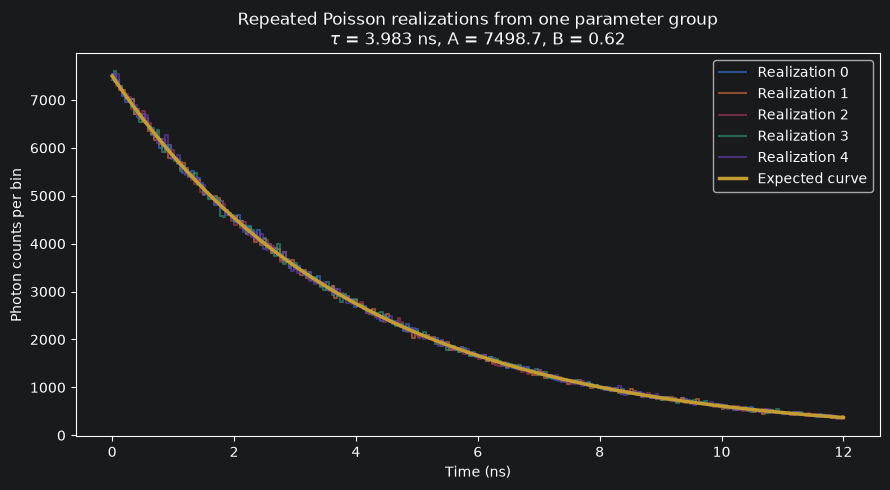

In [39]:
selected_group = 0

selected_indices = np.flatnonzero(
    parameter_groups == selected_group
)

selected_lifetime = group_lifetimes_ns[selected_group]
selected_amplitude = group_amplitudes[selected_group]
selected_background = group_backgrounds[selected_group]

plt.figure(figsize=(9, 5))

for index in selected_indices:
    realization_id = realization_ids[index]

    plt.step(
        time_ns,
        measured_curves[index],
        where="mid",
        alpha=0.65,
        label=f"Realization {realization_id}",
    )

plt.plot(
    time_ns,
    expected_curves[selected_group],
    linewidth=2.5,
    label="Expected curve",
)

plt.xlabel("Time (ns)")
plt.ylabel("Photon counts per bin")
plt.title(
    "Repeated Poisson realizations from one parameter group\n"
    f"$\\tau$ = {selected_lifetime:.3f} ns, "
    f"A = {selected_amplitude:.1f}, "
    f"B = {selected_background:.2f}"
)
plt.legend()
plt.tight_layout()
plt.show()

### Preparation of model inputs

As in the first machine-learning baseline, each measured histogram is normalized by its total photon count:

$$
x_{i,j}^{\mathrm{norm}}
=
\frac{x_{i,j}}{\sum_k x_{i,k}},
$$

where \(i\) indexes the decay curve, \(j\) indexes the time bin, and the sum runs over all time bins \(k\) of curve \(i\).

This removes the overall count scale and makes the initial model input primarily represent the temporal shape of each decay. The unnormalized total photon count is retained separately in the metadata for later noise-dependent evaluation.

Because each curve is normalized using only its own measured counts, this operation does not estimate parameters from the complete dataset and therefore does not transfer population-level information between training and test sets.


In [40]:
curve_totals = measured_curves.sum(
    axis=1,
    keepdims=True,
)

if np.any(curve_totals == 0):
    raise ValueError(
        "At least one simulated curve contains zero total counts."
    )

X = (
    measured_curves.astype(np.float64)
    / curve_totals
)

y = curve_lifetimes_ns.copy()
groups = parameter_groups.copy()

In [41]:
row_sums = X.sum(axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("Minimum normalized row sum:", row_sums.min())
print("Maximum normalized row sum:", row_sums.max())

assert np.allclose(row_sums, 1.0)

X shape: (2500, 256)
y shape: (2500,)
groups shape: (2500,)
Minimum normalized row sum: 0.9999999999999996
Maximum normalized row sum: 1.0000000000000004


## 3. Naive row-wise random split

A conventional machine-learning workflow often treats every row of the feature matrix as an independent observation and randomly assigns rows to training and
test subsets.

For the present dataset, such a split operates at the level of individual Poisson realizations:

```text
curve 0  ──► training or test
curve 1  ──► training or test
curve 2  ──► training or test
```

The splitting algorithm does not know that several rows may share the same lifetime, amplitude, background, and expected decay curve. It therefore does not prevent different realizations from one parameter group from appearing in both subsets.

This section intentionally applies that naive row-wise strategy. It provides a reference evaluation protocol that will later be compared with a group-aware split.

The split is performed using row indices. Retaining the indices makes it possible to apply exactly the same assignment to the feature matrix, target array, group labels, and metadata table.

The phrase **naive** does not mean that `train_test_split()` is generally a bad function. It means that row-wise splitting is naive **for this particular hierarchical dataset** because the rows are not independent physical cases.

In [42]:
random_test_size = 0.20
split_random_state = 42

all_indices = np.arange(
    X.shape[0],
    dtype=np.int64,
)

(
    random_train_indices,
    random_test_indices,
) = train_test_split(
    all_indices,
    test_size=random_test_size,
    random_state=split_random_state,
    shuffle=True,
)

In [43]:
print(
    "Number of random training indices:",
    random_train_indices.size,
)
print(
    "Number of random test indices:",
    random_test_indices.size,
)
print(
    "Total number of assigned indices:",
    random_train_indices.size
    + random_test_indices.size,
)

Number of random training indices: 2000
Number of random test indices: 500
Total number of assigned indices: 2500


In [44]:
assert random_train_indices.size == 2000
assert random_test_indices.size == 500

assert np.intersect1d(
    random_train_indices,
    random_test_indices,
).size == 0

combined_random_indices = np.concatenate(
    [
        random_train_indices,
        random_test_indices,
    ]
)

assert np.array_equal(
    np.sort(combined_random_indices),
    all_indices,
)

In [45]:
X_train_random = X[random_train_indices]
X_test_random = X[random_test_indices]

y_train_random = y[random_train_indices]
y_test_random = y[random_test_indices]

groups_train_random = groups[random_train_indices]
groups_test_random = groups[random_test_indices]

In [46]:
metadata_train_random = (
    curve_metadata
    .iloc[random_train_indices]
    .reset_index(drop=True)
)

metadata_test_random = (
    curve_metadata
    .iloc[random_test_indices]
    .reset_index(drop=True)
)

In [47]:
print("Random row-level split")
print("----------------------")
print("X_train shape:", X_train_random.shape)
print("X_test shape: ", X_test_random.shape)
print("y_train shape:", y_train_random.shape)
print("y_test shape: ", y_test_random.shape)
print(
    "Training metadata shape:",
    metadata_train_random.shape,
)
print(
    "Test metadata shape:    ",
    metadata_test_random.shape,
)

Random row-level split
----------------------
X_train shape: (2000, 256)
X_test shape:  (500, 256)
y_train shape: (2000,)
y_test shape:  (500,)
Training metadata shape: (2000, 7)
Test metadata shape:     (500, 7)


In [48]:
assert X_train_random.shape == (
    random_train_indices.size,
    n_time_bins,
)

assert X_test_random.shape == (
    random_test_indices.size,
    n_time_bins,
)

assert y_train_random.shape == (
    random_train_indices.size,
)

assert y_test_random.shape == (
    random_test_indices.size,
)

assert groups_train_random.shape == y_train_random.shape
assert groups_test_random.shape == y_test_random.shape

assert len(metadata_train_random) == X_train_random.shape[0]
assert len(metadata_test_random) == X_test_random.shape[0]

assert (
    X_train_random.shape[0]
    + X_test_random.shape[0]
    == n_curves
)

In [49]:
assert np.array_equal(
    metadata_train_random["curve_id"].to_numpy(),
    curve_ids[random_train_indices],
)

assert np.array_equal(
    metadata_test_random["curve_id"].to_numpy(),
    curve_ids[random_test_indices],
)

assert np.allclose(
    metadata_train_random["lifetime_ns"].to_numpy(),
    y_train_random,
)

assert np.allclose(
    metadata_test_random["lifetime_ns"].to_numpy(),
    y_test_random,
)

assert np.array_equal(
    metadata_train_random[
        "parameter_group"
    ].to_numpy(),
    groups_train_random,
)

assert np.array_equal(
    metadata_test_random[
        "parameter_group"
    ].to_numpy(),
    groups_test_random,
)

In [50]:
metadata_train_random.head()

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,2055,411,0,3,8828,9,629889
1,1961,392,1,3,2814,1,186123
2,1864,372,4,2,9802,4,449726
3,2326,465,1,3,5079,6,384421
4,461,92,1,2,3421,2,183871


In [51]:
metadata_test_random.head()

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,1447,289,2,0,6206,5,131035
1,1114,222,4,3,840,8,62958
2,1064,212,4,1,8239,5,250988
3,2287,457,2,2,5417,4,295417
4,1537,307,2,3,2142,6,152135


### Target distributions under the random split

Because rows are assigned randomly, the training and test subsets are expected to contain similar lifetime distributions. Similar target distributions are useful for measuring interpolation within the simulated lifetime range.

However, distributional similarity alone does not guarantee independence. Training and test curves may have similar lifetime distributions either because they contain different physical parameter combinations or because they contain different Poisson realizations of the same combinations.

In [52]:
random_target_summary = pd.DataFrame(
    {
        "training": pd.Series(y_train_random).describe(),
        "test": pd.Series(y_test_random).describe(),
    }
)

random_target_summary

,training,test
count,2000,500
mean,2,2
std,1,1
min,0,0
25%,1,1
50%,2,2
75%,3,3
max,4,4


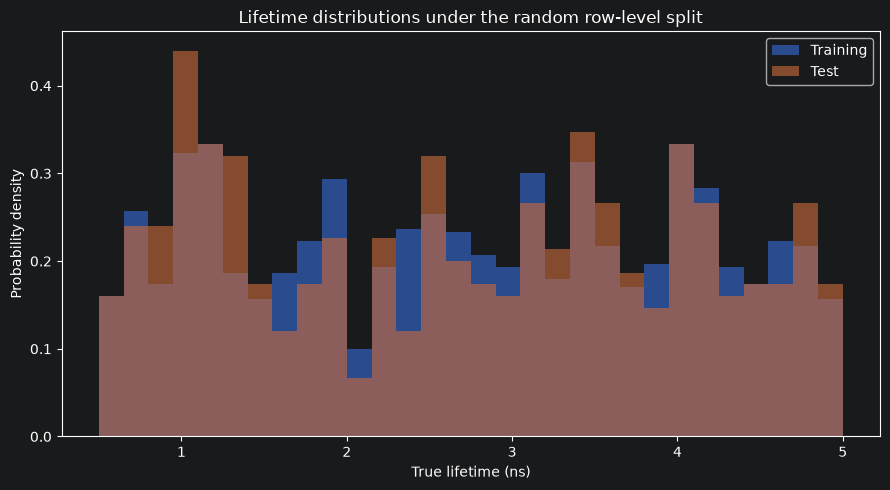

In [53]:
lifetime_bin_edges = np.linspace(
    lifetime_range_ns[0],
    lifetime_range_ns[1],
    31,
)

plt.figure(figsize=(9, 5))

plt.hist(
    y_train_random,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Training",
)

plt.hist(
    y_test_random,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Test",
)

plt.xlabel("True lifetime (ns)")
plt.ylabel("Probability density")
plt.title(
    "Lifetime distributions under the random row-level split"
)
plt.legend()
plt.tight_layout()
plt.show()

### Photon-count distributions under the random split

The total number of measured photons influences the magnitude of relative Poisson fluctuations. It is therefore useful to verify whether the random split creates comparable photon-count distributions in the training and test sets.

At this stage, the purpose is descriptive. A dedicated experiment with deliberately separated photon-count regimes will be performed later to evaluate robustness to new noise conditions.

In [54]:
train_total_counts_random = (
    metadata_train_random[
        "measured_total_counts"
    ].to_numpy()
)

test_total_counts_random = (
    metadata_test_random[
        "measured_total_counts"
    ].to_numpy()
)

In [55]:
random_count_summary = pd.DataFrame(
    {
        "training": pd.Series(
            train_total_counts_random
        ).describe(),
        "test": pd.Series(
            test_total_counts_random
        ).describe(),
    }
)

random_count_summary

,training,test
count,2000,500
mean,290704,298243
std,209377,223476
min,12448,15169
25%,124598,124628
50%,233945,219912
75%,424766,453437
max,933951,931607


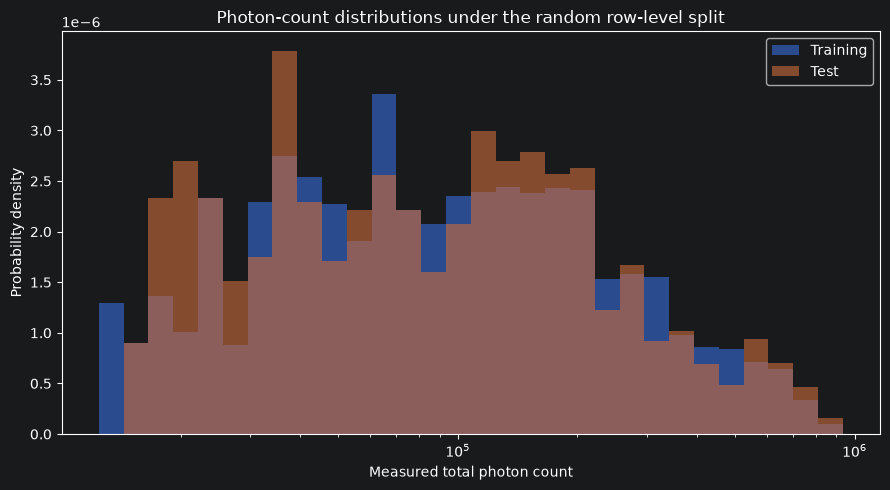

In [56]:
positive_total_counts = curve_metadata.loc[
    curve_metadata["measured_total_counts"] > 0,
    "measured_total_counts",
].to_numpy()

count_bin_edges = np.geomspace(
    positive_total_counts.min(),
    positive_total_counts.max(),
    31,
)

plt.figure(figsize=(9, 5))

plt.hist(
    train_total_counts_random,
    bins=count_bin_edges,
    density=True,
    alpha=0.6,
    label="Training",
)

plt.hist(
    test_total_counts_random,
    bins=count_bin_edges,
    density=True,
    alpha=0.6,
    label="Test",
)

plt.xscale("log")
plt.xlabel("Measured total photon count")
plt.ylabel("Probability density")
plt.title(
    "Photon-count distributions under the random row-level split"
)
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
n_train_groups_random = np.unique(
    groups_train_random
).size

n_test_groups_random = np.unique(
    groups_test_random
).size

print(
    "Unique parameter groups represented in training:",
    n_train_groups_random,
)
print(
    "Unique parameter groups represented in test:",
    n_test_groups_random,
)
print(
    "Total parameter groups in the dataset:",
    n_parameter_groups,
)

Unique parameter groups represented in training: 500
Unique parameter groups represented in test: 329
Total parameter groups in the dataset: 500


### Interpretation of the naive split

The random row-level procedure creates two disjoint sets of measured curves:

* no individual histogram appears in both subsets;
* all curves are assigned exactly once;
* the training and test subsets have similar lifetime distributions;
* the training and test subsets have similar photon-count distributions.

These properties make the split look statistically reasonable when each row is treated as an independent observation.

However, row-level disjointness is not equivalent to parameter-group disjointness. Because the splitting algorithm ignored `parameter_group`, different Poisson realizations of the same expected decay may occur in both subsets.

The random split therefore answers the relatively limited question:

> How accurately can the model predict randomly withheld Poisson realizations
> drawn from the same overall simulation campaign?

It does not necessarily answer the stronger question:

> How accurately can the model predict curves generated from unfamiliar
> physical parameter combinations?

The next section constructs a group-aware split in which all realizations from one parameter group are kept together.

## 4. Parameter-group split

The naive split treated every measured histogram as an independent row. A group-aware split instead treats the underlying simulation parameter set as the indivisible observation.

All Poisson realizations generated from one expected decay must be assigned to the same subset:

```text
parameter group
├── realization 0
├── realization 1
├── realization 2
├── realization 3
└── realization 4
        ↓
training or test, but not both
```

This prevents the model from being trained on one noisy realization of an expected decay and tested on another realization of that same decay. The split will be created using `GroupShuffleSplit`. The feature matrix and target values are still divided at the curve level, but the group labels constrain which curves may be separated.

The key distinction is:

```text
Naive split:
individual rows are shuffled independently

Group-aware split:
groups are shuffled, and rows follow their groups
```

In [60]:
group_test_size = 0.20
group_split_random_state = 42

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=group_test_size,
    random_state=group_split_random_state,
)

(
    grouped_train_indices,
    grouped_test_indices,
) = next(
    group_splitter.split(
        X,
        y,
        groups=groups,
    )
)

In [61]:
print(
    "Number of grouped training indices:",
    grouped_train_indices.size,
)
print(
    "Number of grouped test indices:",
    grouped_test_indices.size,
)
print(
    "Total number of assigned indices:",
    grouped_train_indices.size
    + grouped_test_indices.size,
)

Number of grouped training indices: 2000
Number of grouped test indices: 500
Total number of assigned indices: 2500


In [62]:
assert (
    grouped_train_indices.size
    + grouped_test_indices.size
    == n_curves
)

assert np.intersect1d(
    grouped_train_indices,
    grouped_test_indices,
).size == 0

combined_grouped_indices = np.concatenate(
    [
        grouped_train_indices,
        grouped_test_indices,
    ]
)

assert np.array_equal(
    np.sort(combined_grouped_indices),
    all_indices,
)

In [63]:
X_train_grouped = X[grouped_train_indices]
X_test_grouped = X[grouped_test_indices]

y_train_grouped = y[grouped_train_indices]
y_test_grouped = y[grouped_test_indices]

groups_train_grouped = groups[grouped_train_indices]
groups_test_grouped = groups[grouped_test_indices]

In [64]:
metadata_train_grouped = (
    curve_metadata
    .iloc[grouped_train_indices]
    .reset_index(drop=True)
)

metadata_test_grouped = (
    curve_metadata
    .iloc[grouped_test_indices]
    .reset_index(drop=True)
)

In [65]:
print("Group-aware split")
print("-----------------")
print("X_train shape:", X_train_grouped.shape)
print("X_test shape: ", X_test_grouped.shape)
print("y_train shape:", y_train_grouped.shape)
print("y_test shape: ", y_test_grouped.shape)
print(
    "Training metadata shape:",
    metadata_train_grouped.shape,
)
print(
    "Test metadata shape:    ",
    metadata_test_grouped.shape,
)

Group-aware split
-----------------
X_train shape: (2000, 256)
X_test shape:  (500, 256)
y_train shape: (2000,)
y_test shape:  (500,)
Training metadata shape: (2000, 7)
Test metadata shape:     (500, 7)


In [66]:
assert X_train_grouped.shape == (
    grouped_train_indices.size,
    n_time_bins,
)

assert X_test_grouped.shape == (
    grouped_test_indices.size,
    n_time_bins,
)

assert y_train_grouped.shape == (
    grouped_train_indices.size,
)

assert y_test_grouped.shape == (
    grouped_test_indices.size,
)

assert (
    groups_train_grouped.shape
    == y_train_grouped.shape
)

assert (
    groups_test_grouped.shape
    == y_test_grouped.shape
)

assert (
    len(metadata_train_grouped)
    == X_train_grouped.shape[0]
)

assert (
    len(metadata_test_grouped)
    == X_test_grouped.shape[0]
)

In [67]:
assert np.array_equal(
    metadata_train_grouped[
        "curve_id"
    ].to_numpy(),
    curve_ids[grouped_train_indices],
)

assert np.array_equal(
    metadata_test_grouped[
        "curve_id"
    ].to_numpy(),
    curve_ids[grouped_test_indices],
)

assert np.allclose(
    metadata_train_grouped[
        "lifetime_ns"
    ].to_numpy(),
    y_train_grouped,
)

assert np.allclose(
    metadata_test_grouped[
        "lifetime_ns"
    ].to_numpy(),
    y_test_grouped,
)

assert np.array_equal(
    metadata_train_grouped[
        "parameter_group"
    ].to_numpy(),
    groups_train_grouped,
)

assert np.array_equal(
    metadata_test_grouped[
        "parameter_group"
    ].to_numpy(),
    groups_test_grouped,
)

In [68]:
unique_train_groups_grouped = np.unique(
    groups_train_grouped
)

unique_test_groups_grouped = np.unique(
    groups_test_grouped
)

n_train_groups_grouped = (
    unique_train_groups_grouped.size
)

n_test_groups_grouped = (
    unique_test_groups_grouped.size
)

print(
    "Unique parameter groups represented in training:",
    n_train_groups_grouped,
)
print(
    "Unique parameter groups represented in test:",
    n_test_groups_grouped,
)
print(
    "Total represented groups:",
    n_train_groups_grouped
    + n_test_groups_grouped,
)

Unique parameter groups represented in training: 400
Unique parameter groups represented in test: 100
Total represented groups: 500


In [69]:
assert n_train_groups_grouped == 400
assert n_test_groups_grouped == 100

assert (
    n_train_groups_grouped
    + n_test_groups_grouped
    == n_parameter_groups
)

In [70]:
train_group_sizes_grouped = (
    metadata_train_grouped
    .groupby("parameter_group")
    .size()
)

test_group_sizes_grouped = (
    metadata_test_grouped
    .groupby("parameter_group")
    .size()
)

print(
    "Unique training-group sizes:",
    train_group_sizes_grouped.unique(),
)
print(
    "Unique test-group sizes:",
    test_group_sizes_grouped.unique(),
)

Unique training-group sizes: [5]
Unique test-group sizes: [5]


In [71]:
assert np.all(
    train_group_sizes_grouped.to_numpy()
    == n_realizations_per_group
)

assert np.all(
    test_group_sizes_grouped.to_numpy()
    == n_realizations_per_group
)

In [72]:
metadata_train_grouped.sort_values(
    [
        "parameter_group",
        "realization_id",
    ]
).head(10)

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,5,1,0,2,8920,4,470429
1,6,1,1,2,8920,4,470395
2,7,1,2,2,8920,4,470939
3,8,1,3,2,8920,4,471519
4,9,1,4,2,8920,4,470882
5,15,3,0,3,5284,1,396605
6,16,3,1,3,5284,1,396686
7,17,3,2,3,5284,1,396208
8,18,3,3,3,5284,1,396708
9,19,3,4,3,5284,1,395858


In [73]:
metadata_test_grouped.sort_values(
    [
        "parameter_group",
        "realization_id",
    ]
).head(10)

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,0,0,0,3,7498,0,608338
1,1,0,1,3,7498,0,607223
2,2,0,2,3,7498,0,606840
3,3,0,3,3,7498,0,608589
4,4,0,4,3,7498,0,607563
5,10,2,0,4,9250,1,806380
6,11,2,1,4,9250,1,809886
7,12,2,2,4,9250,1,808204
8,13,2,3,4,9250,1,807797
9,14,2,4,4,9250,1,807015


### Target distributions under the grouped split

`GroupShuffleSplit` separates parameter groups but does not explicitly balance the target lifetime distribution.

Because the group lifetimes were independently sampled from the same continuous uniform distribution, the training and test lifetime distributions should usually remain broadly similar. Small differences may nevertheless occur because only 100 parameter groups are assigned to the test set.

The grouped test set therefore evaluates interpolation to new parameter combinations within approximately the same overall lifetime range.

In [74]:
grouped_target_summary = pd.DataFrame(
    {
        "training": pd.Series(
            y_train_grouped
        ).describe(),
        "test": pd.Series(
            y_test_grouped
        ).describe(),
    }
)

grouped_target_summary

,training,test
count,2000,500
mean,2,2
std,1,1
min,0,0
25%,1,1
50%,2,2
75%,3,3
max,4,4


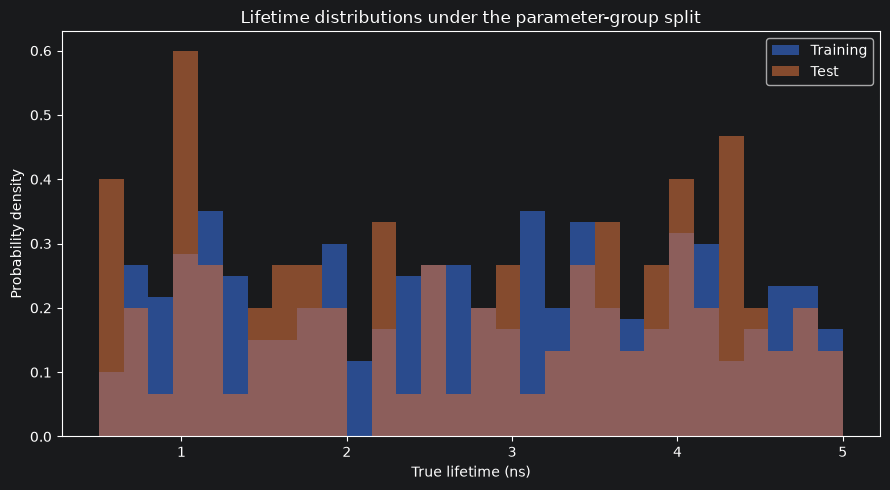

In [75]:
plt.figure(figsize=(9, 5))

plt.hist(
    y_train_grouped,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Training",
)

plt.hist(
    y_test_grouped,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Test",
)

plt.xlabel("True lifetime (ns)")
plt.ylabel("Probability density")
plt.title(
    "Lifetime distributions under the parameter-group split"
)
plt.legend()
plt.tight_layout()
plt.show()

### Distribution of unique group lifetimes

Every lifetime occurs once per parameter group but is repeated for each Poisson realization in the curve-level target arrays. To display the physical parameter distribution directly, one lifetime can be retained for each unique group.

In [76]:
train_group_lifetimes = (
    metadata_train_grouped
    .groupby("parameter_group")["lifetime_ns"]
    .first()
    .to_numpy()
)

test_group_lifetimes = (
    metadata_test_grouped
    .groupby("parameter_group")["lifetime_ns"]
    .first()
    .to_numpy()
)

In [77]:
assert train_group_lifetimes.size == 400
assert test_group_lifetimes.size == 100

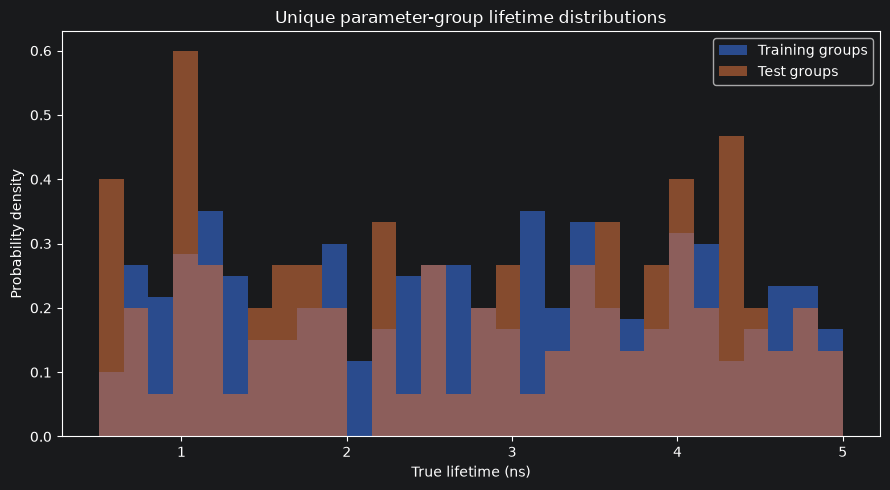

In [78]:
plt.figure(figsize=(9, 5))

plt.hist(
    train_group_lifetimes,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Training groups",
)

plt.hist(
    test_group_lifetimes,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Test groups",
)

plt.xlabel("True lifetime (ns)")
plt.ylabel("Probability density")
plt.title(
    "Unique parameter-group lifetime distributions"
)
plt.legend()
plt.tight_layout()
plt.show()

### Photon-count distributions under the grouped split

Although all realizations within one parameter group share the same expected curve, their measured total counts vary because of Poisson sampling.

The grouped split separates complete physical parameter sets. Consequently, differences in photon-count distributions can arise from both:

* different amplitudes, backgrounds, and lifetimes assigned to the selected
  groups;
* stochastic variation among Poisson realizations within those groups.

The present grouped experiment does not deliberately separate photon-count regimes. It only prevents shared parameter combinations across the split.

In [79]:
train_total_counts_grouped = (
    metadata_train_grouped[
        "measured_total_counts"
    ].to_numpy()
)

test_total_counts_grouped = (
    metadata_test_grouped[
        "measured_total_counts"
    ].to_numpy()
)

In [80]:
grouped_count_summary = pd.DataFrame(
    {
        "training": pd.Series(
            train_total_counts_grouped
        ).describe(),
        "test": pd.Series(
            test_total_counts_grouped
        ).describe(),
    }
)

grouped_count_summary

,training,test
count,2000,500
mean,287097,312671
std,211064,215919
min,12448,28751
25%,118293,145887
50%,220272,263115
75%,424373,446179
max,933951,809886


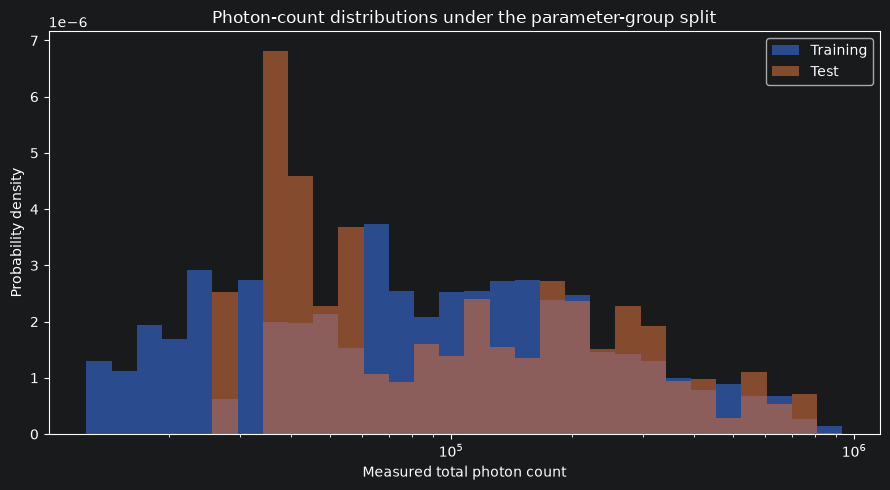

In [81]:
plt.figure(figsize=(9, 5))

plt.hist(
    train_total_counts_grouped,
    bins=count_bin_edges,
    density=True,
    alpha=0.6,
    label="Training",
)

plt.hist(
    test_total_counts_grouped,
    bins=count_bin_edges,
    density=True,
    alpha=0.6,
    label="Test",
)

plt.xscale("log")
plt.xlabel("Measured total photon count")
plt.ylabel("Probability density")
plt.title(
    "Photon-count distributions under the parameter-group split"
)
plt.legend()
plt.tight_layout()
plt.show()

### Comparison of subset sizes

The random and grouped protocols contain the same number of training and test curves. Therefore, later differences in model performance cannot be attributed simply to unequal sample counts.

The protocols differ in which relationships between observations are allowed across the split.

In [82]:
split_size_comparison = pd.DataFrame(
    {
        "protocol": [
            "Random row-level",
            "Parameter-group",
        ],
        "training_curves": [
            X_train_random.shape[0],
            X_train_grouped.shape[0],
        ],
        "test_curves": [
            X_test_random.shape[0],
            X_test_grouped.shape[0],
        ],
        "training_unique_groups": [
            n_train_groups_random,
            n_train_groups_grouped,
        ],
        "test_unique_groups": [
            n_test_groups_random,
            n_test_groups_grouped,
        ],
    }
)

split_size_comparison

,protocol,training_curves,test_curves,training_unique_groups,test_unique_groups
0,Random row-level,2000,500,500,329
1,Parameter-group,2000,500,400,100


### Interpretation of the parameter-group split

The group-aware procedure preserves the complete simulation hierarchy:

* every measured curve is assigned exactly once;
* every parameter group retains all of its Poisson realizations;
* approximately 80% of parameter groups are used for training;
* approximately 20% of parameter groups are reserved for testing;
* the training and test subsets remain within the same broad simulated
  lifetime and photon-count ranges.

Unlike the naive row-level split, this procedure does not allow an expected decay curve to contribute noisy realizations to both subsets.

The grouped protocol therefore asks a stronger question:

> How accurately can the model predict Poisson-sampled curves generated from
> parameter combinations that were not represented during training?

This remains an interpolation experiment because the held-out lifetimes, amplitudes, and backgrounds are sampled from the same overall parameter ranges as the training groups. It is not yet a test of extrapolation, unfamiliar noise regimes, model mismatch, or unfamiliar IRFs.

The next section verifies the defining property of the two protocols by measuring parameter-group overlap between their training and test subsets.